# Deutsch–Jozsa Algorithm(DJA) with Rotation gate

In realistic quantum systems, qubits can be affected by noise during the computation.  
To study this in the DJA, we introduce single-qubit rotation errors at different points of the algorithm.

We consider rotation errors applied to a single qubit along one of the Pauli axes \(X\), \(Y\), or \(Z\)

1. Before the first H_affects the initial superposition  
2. After the first H– affects the superposed state before the oracle  
3. After the oracle \(U_f\) – affects the phase-amplified state  
4. After the final H– affects the final interference pattern before measurement  

In [1]:
from quantum_algorithms import (
    I, X, Y, Z, H, P0, P1,
    rotation_gate, U_N_qubits, U_one_gate, U_two_gates,
    initial_state, apply_hadamards,
    sample_probs, oracle_function,
    f_constant_0, f_constant_1, f_balanced_parity,
    measure_probs_first_n, sample_measurements_input,
    deutsch_jozsa,
    deutsch_jozsa_error1,
    deutsch_jozsa_error2,
    deutsch_jozsa_error3,
    deutsch_jozsa_error4
)

In [70]:
import numpy as np

# Parameters
n = 1
theta = np.pi / 4        
target_qubit = 0         
axis = (1, 0, 0)         

# --- Original Deutsch–Jozsa (no error) ---
state_const = deutsch_jozsa(n, f_constant_0)
state_bal   = deutsch_jozsa(n, f_balanced_parity)

probs_const = measure_probs_first_n(state_const, n)
probs_bal   = measure_probs_first_n(state_bal, n)

print("DJA")
print("P(0^n) constant ", probs_const[0])
print("P(0^n) balanced ", probs_bal[0])
print()

#Error1(E1) (before Hadamards)
state_const1 = deutsch_jozsa_error1(n, f_constant_0, theta, target_qubit, axis)
state_bal1   = deutsch_jozsa_error1(n, f_balanced_parity, theta, target_qubit, axis)

probs_const = measure_probs_first_n(state_const1, n)
probs_bal   = measure_probs_first_n(state_bal1, n)

print("DJA with E1 (before H)")
print("P(0^n) constant ", probs_const[0])
print("P(0^n) balanced ", probs_bal[0])
print()

# Error2(E2) (after first Hadamards)
state_const2 = deutsch_jozsa_error2(n, f_constant_0, theta, target_qubit, axis)
state_bal2   = deutsch_jozsa_error2(n, f_balanced_parity, theta, target_qubit, axis)

probs_const = measure_probs_first_n(state_const2, n)
probs_bal   = measure_probs_first_n(state_bal2, n)

print("DJA with E2 (after first H)")
print("P(0^n) constant ", probs_const[0])
print("P(0^n) balanced ", probs_bal[0])
print()

# Error3(E3) (after oracle)
state_const3 = deutsch_jozsa_error3(n, f_constant_0, theta, target_qubit, axis)
state_bal3   = deutsch_jozsa_error3(n, f_balanced_parity, theta, target_qubit, axis)

probs_const = measure_probs_first_n(state_const3, n)
probs_bal   = measure_probs_first_n(state_bal3, n)

print("DJA with E3 (after oracle)")
print("P(0^n) constant ", probs_const[0])
print("P(0^n) balanced ", probs_bal[0])
print()

# Error4(E4) (after final Hadamards)
state_for_constant4= deutsch_jozsa_error4(n, f_constant_0, theta, target_qubit, axis)
state_for_balanced4= deutsch_jozsa_error4(n, f_balanced_parity, theta, target_qubit, axis)

probs_const = measure_probs_first_n(state_for_constant4, n)
probs_bal   = measure_probs_first_n(state_for_balanced4, n)

print("DJA with E4 (after final H)")
print("P(0^n) constant ", probs_const[0])
print("P(0^n) balanced ", probs_bal[0])

DJA
P(0^n) constant  0.9999999999999996
P(0^n) balanced  1.0573994819069698e-33

DJA with E1 (before H)
P(0^n) constant  0.853553390593273
P(0^n) balanced  0.14644660940672613

DJA with E2 (after first H)
P(0^n) constant  0.9999999999999992
P(0^n) balanced  6.624483918491784e-36

DJA with E3 (after oracle)
P(0^n) constant  0.9999999999999992
P(0^n) balanced  6.624483918491784e-36

DJA with E4 (after final H)
P(0^n) constant  0.8535533905932733
P(0^n) balanced  0.14644660940672619


In [66]:
import numpy as np
from collections import Counter

n = 2
theta = np.pi / 4        
target_qubit = 0         
axis = (1, 0, 0)         

state_const = deutsch_jozsa(n, f_constant_0)
state_bal   = deutsch_jozsa(n, f_balanced_parity)

probs_const = measure_probs_first_n(state_const, n)
probs_bal   = measure_probs_first_n(state_bal, n)

print("Original DJA:")
print("P(0*n) constant =", probs_const[0])
print("P(0*n) balanced =", probs_bal[0])
print()

state_const1 = deutsch_jozsa_error1(n, f_constant_0, theta, target_qubit, axis)
state_bal1   = deutsch_jozsa_error1(n, f_balanced_parity, theta, target_qubit, axis)

probs_const = measure_probs_first_n(state_const1, n)
probs_bal   = measure_probs_first_n(state_bal1, n)

print("DJA with Error1 (before H):")
print("P(0*n) constant =", probs_const[0])
print("P(0*n) balanced =", probs_bal[0])
print()


state_const2 = deutsch_jozsa_error2(n, f_constant_0, theta, target_qubit, axis)
state_bal2   = deutsch_jozsa_error2(n, f_balanced_parity, theta, target_qubit, axis)

probs_const = measure_probs_first_n(state_const2, n)
probs_bal   = measure_probs_first_n(state_bal2, n)

print("DJA with Error2 (after first H):")
print("P(0*n) constant =", probs_const[0])
print("P(0*n) balanced =", probs_bal[0])
print()


state_const3 = deutsch_jozsa_error3(n, f_constant_0, theta, target_qubit, axis)
state_bal3   = deutsch_jozsa_error3(n, f_balanced_parity, theta, target_qubit, axis)

probs_const = measure_probs_first_n(state_const3, n)
probs_bal   = measure_probs_first_n(state_bal3, n)

print("DJA with Error3 (after oracle):")
print("P(0*n) constant =", probs_const[0])
print("P(0*n) balanced =", probs_bal[0])
print()

state_const4 = deutsch_jozsa_error4(n, f_constant_0, theta, target_qubit, axis)
state_bal4   = deutsch_jozsa_error4(n, f_balanced_parity, theta, target_qubit, axis)

probs_const = measure_probs_first_n(state_const4, n)
probs_bal   = measure_probs_first_n(state_bal4, n)

print("DJA with Error4 (after final H):")
print("P(0*n) constant =", probs_const[0])
print("P(0*n) balanced =", probs_bal[0])

Original DJA:
P(0*n) constant = 0.9999999999999989
P(0*n) balanced = 2.643498704767422e-34

DJA with Error1 (before H):
P(0*n) constant = 0.853553390593273
P(0*n) balanced = 1.474152541086386e-34

DJA with Error2 (after first H):
P(0*n) constant = 0.9999999999999992
P(0*n) balanced = 1.474152541086386e-34

DJA with Error3 (after oracle):
P(0*n) constant = 0.9999999999999992
P(0*n) balanced = 1.474152541086386e-34

DJA with Error4 (after final H):
P(0*n) constant = 0.8535533905932726
P(0*n) balanced = 3.030630127051684e-34


In [38]:
import numpy as np
from collections import Counter

n = 2
theta = np.pi / 4        
target_qubit = 1       
axis = (1, 0, 0)         

state_const = deutsch_jozsa(n, f_constant_0)
state_bal   = deutsch_jozsa(n, f_balanced_parity)

probs_const = measure_probs_first_n(state_const, n)
probs_bal   = measure_probs_first_n(state_bal, n)

print("Original DJA:")
print("P(0*n) constant =", probs_const[0])
print("P(0*n) balanced =", probs_bal[0])
print()

state_const1 = deutsch_jozsa_error1(n, f_constant_0, theta, target_qubit, axis)
state_bal1   = deutsch_jozsa_error1(n, f_balanced_parity, theta, target_qubit, axis)

probs_const = measure_probs_first_n(state_const1, n)
probs_bal   = measure_probs_first_n(state_bal1, n)

print("DJA with Error1 (before H):")
print("P(0*n) constant =", probs_const[0])
print("P(0*n) balanced =", probs_bal[0])
print()


state_const2 = deutsch_jozsa_error2(n, f_constant_0, theta, target_qubit, axis)
state_bal2   = deutsch_jozsa_error2(n, f_balanced_parity, theta, target_qubit, axis)

probs_const = measure_probs_first_n(state_const2, n)
probs_bal   = measure_probs_first_n(state_bal2, n)

print("DJA with Error2 (after first H):")
print("P(0*n) constant =", probs_const[0])
print("P(0*n) balanced =", probs_bal[0])
print()


state_const3 = deutsch_jozsa_error3(n, f_constant_0, theta, target_qubit, axis)
state_bal3   = deutsch_jozsa_error3(n, f_balanced_parity, theta, target_qubit, axis)

probs_const = measure_probs_first_n(state_const3, n)
probs_bal   = measure_probs_first_n(state_bal3, n)

print("DJA with Error3 (after oracle):")
print("P(0*n) constant =", probs_const[0])
print("P(0*n) balanced =", probs_bal[0])
print()

state_const4 = deutsch_jozsa_error4(n, f_constant_0, theta, target_qubit, axis)
state_bal4   = deutsch_jozsa_error4(n, f_balanced_parity, theta, target_qubit, axis)

probs_const = measure_probs_first_n(state_const4, n)
probs_bal   = measure_probs_first_n(state_bal4, n)

print("DJA with Error4 (after final H):")
print("P(0*n) constant =", probs_const[0])
print("P(0*n) balanced =", probs_bal[0])

Original DJA:
P(|0^n>) constant = 0.9999999999999989
P(|0^n>) balanced = 2.643498704767422e-34

DJA with Error1 (before H):
P(|0^n>) constant = 0.853553390593273
P(|0^n>) balanced = 0.14644660940672613

DJA with Error2 (after first H):
P(|0^n>) constant = 0.9999999999999992
P(|0^n>) balanced = 1.474152541086386e-34

DJA with Error3 (after oracle):
P(|0^n>) constant = 0.9999999999999992
P(|0^n>) balanced = 1.474152541086386e-34

DJA with Error4 (after final H):
P(|0^n>) constant = 0.8535533905932726
P(|0^n>) balanced = 0.14644660940672607


In [35]:
import numpy as np
from collections import Counter

shots = 1024
n = 9
theta = np.pi / 4
target_qubit = 0
axis = (1, 0, 0)

state_const = deutsch_jozsa(n, f_constant_1)
state_bal   = deutsch_jozsa(n, f_balanced_parity)

samples_const = sample_measurements_input(state_const, n, shots)
samples_bal   = sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = deutsch_jozsa_error1(n, f_constant_1, theta, target_qubit, axis)
state_bal1   = deutsch_jozsa_error1(n, f_balanced_parity, theta, target_qubit, axis)

samples_const1 = sample_measurements_input(state_const1, n, shots)
samples_bal1   = sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = deutsch_jozsa_error2(n, f_constant_1, theta, target_qubit, axis)
state_bal2   = deutsch_jozsa_error2(n, f_balanced_parity, theta, target_qubit, axis)

samples_const2 = sample_measurements_input(state_const2, n, shots)
samples_bal2   = sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = deutsch_jozsa_error3(n, f_constant_1, theta, target_qubit, axis)
state_bal3   = deutsch_jozsa_error3(n, f_balanced_parity, theta, target_qubit, axis)

samples_const3 = sample_measurements_input(state_const3, n, shots)
samples_bal3   = sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = deutsch_jozsa_error4(n, f_constant_1, theta, target_qubit, axis)
state_bal4   = deutsch_jozsa_error4(n, f_balanced_parity, theta, target_qubit, axis)

samples_const4 = sample_measurements_input(state_const4, n, shots)
samples_bal4   = sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

Original DJA
constant: Counter({0: 1024})
balanced: Counter({1: 1024})

Error 1 (before Hadamards)
constant: Counter({0: 861, 256: 163})
balanced: Counter({1: 872, 257: 152})

Error 2 (after first Hadamards)
constant: Counter({0: 1024})
balanced: Counter({1: 1024})

Error 3 (after oracle)
constant: Counter({0: 1024})
balanced: Counter({1: 1024})

Error 4 (after final Hadamards)
constant: Counter({0: 865, 256: 159})
balanced: Counter({1: 875, 257: 149})


In [39]:
import numpy as np
from collections import Counter

shots = 1024
n = 9
theta = np.pi / 4
target_qubit = 3
axis = (1, 0, 0)

state_const = deutsch_jozsa(n, f_constant_1)
state_bal   = deutsch_jozsa(n, f_balanced_parity)

samples_const = sample_measurements_input(state_const, n, shots)
samples_bal   = sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = deutsch_jozsa_error1(n, f_constant_1, theta, target_qubit, axis)
state_bal1   = deutsch_jozsa_error1(n, f_balanced_parity, theta, target_qubit, axis)

samples_const1 = sample_measurements_input(state_const1, n, shots)
samples_bal1   = sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = deutsch_jozsa_error2(n, f_constant_1, theta, target_qubit, axis)
state_bal2   = deutsch_jozsa_error2(n, f_balanced_parity, theta, target_qubit, axis)

samples_const2 = sample_measurements_input(state_const2, n, shots)
samples_bal2   = sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = deutsch_jozsa_error3(n, f_constant_1, theta, target_qubit, axis)
state_bal3   = deutsch_jozsa_error3(n, f_balanced_parity, theta, target_qubit, axis)

samples_const3 = sample_measurements_input(state_const3, n, shots)
samples_bal3   = sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = deutsch_jozsa_error4(n, f_constant_1, theta, target_qubit, axis)
state_bal4   = deutsch_jozsa_error4(n, f_balanced_parity, theta, target_qubit, axis)

samples_const4 = sample_measurements_input(state_const4, n, shots)
samples_bal4   = sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

Original DJA
constant: Counter({0: 1024})
balanced: Counter({1: 1024})

Error 1 (before Hadamards)
constant: Counter({0: 852, 32: 172})
balanced: Counter({1: 880, 33: 144})

Error 2 (after first Hadamards)
constant: Counter({0: 1024})
balanced: Counter({1: 1024})

Error 3 (after oracle)
constant: Counter({0: 1024})
balanced: Counter({1: 1024})

Error 4 (after final Hadamards)
constant: Counter({0: 893, 32: 131})
balanced: Counter({1: 889, 33: 135})


In [40]:
import numpy as np
from collections import Counter

shots = 1024
n = 9
theta = np.pi / 4
target_qubit = 8
axis = (1, 0, 0)

state_const = deutsch_jozsa(n, f_constant_1)
state_bal   = deutsch_jozsa(n, f_balanced_parity)

samples_const = sample_measurements_input(state_const, n, shots)
samples_bal   = sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = deutsch_jozsa_error1(n, f_constant_1, theta, target_qubit, axis)
state_bal1   = deutsch_jozsa_error1(n, f_balanced_parity, theta, target_qubit, axis)

samples_const1 = sample_measurements_input(state_const1, n, shots)
samples_bal1   = sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = deutsch_jozsa_error2(n, f_constant_1, theta, target_qubit, axis)
state_bal2   = deutsch_jozsa_error2(n, f_balanced_parity, theta, target_qubit, axis)

samples_const2 = sample_measurements_input(state_const2, n, shots)
samples_bal2   = sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = deutsch_jozsa_error3(n, f_constant_1, theta, target_qubit, axis)
state_bal3   = deutsch_jozsa_error3(n, f_balanced_parity, theta, target_qubit, axis)

samples_const3 = sample_measurements_input(state_const3, n, shots)
samples_bal3   = sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = deutsch_jozsa_error4(n, f_constant_1, theta, target_qubit, axis)
state_bal4   = deutsch_jozsa_error4(n, f_balanced_parity, theta, target_qubit, axis)

samples_const4 = sample_measurements_input(state_const4, n, shots)
samples_bal4   = sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

Original DJA
constant: Counter({0: 1024})
balanced: Counter({1: 1024})

Error 1 (before Hadamards)
constant: Counter({0: 869, 1: 155})
balanced: Counter({1: 893, 0: 131})

Error 2 (after first Hadamards)
constant: Counter({0: 1024})
balanced: Counter({1: 1024})

Error 3 (after oracle)
constant: Counter({0: 1024})
balanced: Counter({1: 1024})

Error 4 (after final Hadamards)
constant: Counter({0: 877, 1: 147})
balanced: Counter({1: 893, 0: 131})


In [41]:
import numpy as np
from collections import Counter

shots = 1024
n = 9
theta = np.pi / 4
target_qubit = 7
axis = (1, 0, 0)

state_const = deutsch_jozsa(n, f_constant_1)
state_bal   = deutsch_jozsa(n, f_balanced_parity)

samples_const = sample_measurements_input(state_const, n, shots)
samples_bal   = sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = deutsch_jozsa_error1(n, f_constant_1, theta, target_qubit, axis)
state_bal1   = deutsch_jozsa_error1(n, f_balanced_parity, theta, target_qubit, axis)

samples_const1 = sample_measurements_input(state_const1, n, shots)
samples_bal1   = sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = deutsch_jozsa_error2(n, f_constant_1, theta, target_qubit, axis)
state_bal2   = deutsch_jozsa_error2(n, f_balanced_parity, theta, target_qubit, axis)

samples_const2 = sample_measurements_input(state_const2, n, shots)
samples_bal2   = sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = deutsch_jozsa_error3(n, f_constant_1, theta, target_qubit, axis)
state_bal3   = deutsch_jozsa_error3(n, f_balanced_parity, theta, target_qubit, axis)

samples_const3 = sample_measurements_input(state_const3, n, shots)
samples_bal3   = sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = deutsch_jozsa_error4(n, f_constant_1, theta, target_qubit, axis)
state_bal4   = deutsch_jozsa_error4(n, f_balanced_parity, theta, target_qubit, axis)

samples_const4 = sample_measurements_input(state_const4, n, shots)
samples_bal4   = sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

Original DJA
constant: Counter({0: 1024})
balanced: Counter({1: 1024})

Error 1 (before Hadamards)
constant: Counter({0: 867, 2: 157})
balanced: Counter({1: 873, 3: 151})

Error 2 (after first Hadamards)
constant: Counter({0: 1024})
balanced: Counter({1: 1024})

Error 3 (after oracle)
constant: Counter({0: 1024})
balanced: Counter({1: 1024})

Error 4 (after final Hadamards)
constant: Counter({0: 895, 2: 129})
balanced: Counter({1: 881, 3: 143})


In [42]:
import numpy as np
from collections import Counter

shots = 1024
n = 9
theta = np.pi / 4
target_qubit = 0
axis = (1, 0, 0)

state_const = deutsch_jozsa(n, f_constant_1)
state_bal   = deutsch_jozsa(n, f_balanced_parity)

samples_const = sample_measurements_input(state_const, n, shots)
samples_bal   = sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = deutsch_jozsa_error1(n, f_constant_1, theta, target_qubit, axis)
state_bal1   = deutsch_jozsa_error1(n, f_balanced_parity, theta, target_qubit, axis)

samples_const1 = sample_measurements_input(state_const1, n, shots)
samples_bal1   = sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = deutsch_jozsa_error2(n, f_constant_1, theta, target_qubit, axis)
state_bal2   = deutsch_jozsa_error2(n, f_balanced_parity, theta, target_qubit, axis)

samples_const2 = sample_measurements_input(state_const2, n, shots)
samples_bal2   = sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = deutsch_jozsa_error3(n, f_constant_1, theta, target_qubit, axis)
state_bal3   = deutsch_jozsa_error3(n, f_balanced_parity, theta, target_qubit, axis)

samples_const3 = sample_measurements_input(state_const3, n, shots)
samples_bal3   = sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = deutsch_jozsa_error4(n, f_constant_1, theta, target_qubit, axis)
state_bal4   = deutsch_jozsa_error4(n, f_balanced_parity, theta, target_qubit, axis)

samples_const4 = sample_measurements_input(state_const4, n, shots)
samples_bal4   = sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

Original DJA
constant: Counter({0: 1024})
balanced: Counter({1: 1024})

Error 1 (before Hadamards)
constant: Counter({0: 871, 256: 153})
balanced: Counter({1: 882, 257: 142})

Error 2 (after first Hadamards)
constant: Counter({0: 1024})
balanced: Counter({1: 1024})

Error 3 (after oracle)
constant: Counter({0: 1024})
balanced: Counter({1: 1024})

Error 4 (after final Hadamards)
constant: Counter({0: 908, 256: 116})
balanced: Counter({1: 872, 257: 152})


In [43]:
import numpy as np
from collections import Counter

shots = 2000
n = 11
theta = np.pi / 4
target_qubit = 0
axis = (1, 0, 0)

state_const = deutsch_jozsa(n, f_constant_1)
state_bal   = deutsch_jozsa(n, f_balanced_parity)

samples_const = sample_measurements_input(state_const, n, shots)
samples_bal   = sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = deutsch_jozsa_error1(n, f_constant_1, theta, target_qubit, axis)
state_bal1   = deutsch_jozsa_error1(n, f_balanced_parity, theta, target_qubit, axis)

samples_const1 = sample_measurements_input(state_const1, n, shots)
samples_bal1   = sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = deutsch_jozsa_error2(n, f_constant_1, theta, target_qubit, axis)
state_bal2   = deutsch_jozsa_error2(n, f_balanced_parity, theta, target_qubit, axis)

samples_const2 = sample_measurements_input(state_const2, n, shots)
samples_bal2   = sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = deutsch_jozsa_error3(n, f_constant_1, theta, target_qubit, axis)
state_bal3   = deutsch_jozsa_error3(n, f_balanced_parity, theta, target_qubit, axis)

samples_const3 = sample_measurements_input(state_const3, n, shots)
samples_bal3   = sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = deutsch_jozsa_error4(n, f_constant_1, theta, target_qubit, axis)
state_bal4   = deutsch_jozsa_error4(n, f_balanced_parity, theta, target_qubit, axis)

samples_const4 = sample_measurements_input(state_const4, n, shots)
samples_bal4   = sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

Original DJA
constant: Counter({0: 2000})
balanced: Counter({1: 2000})

Error 1 (before Hadamards)
constant: Counter({0: 1662, 1024: 338})
balanced: Counter({1: 1707, 1025: 293})

Error 2 (after first Hadamards)
constant: Counter({0: 2000})
balanced: Counter({1: 2000})

Error 3 (after oracle)
constant: Counter({0: 2000})
balanced: Counter({1: 2000})

Error 4 (after final Hadamards)
constant: Counter({0: 1708, 1024: 292})
balanced: Counter({1: 1699, 1025: 301})


In [44]:
import numpy as np
from collections import Counter

shots = 2000
n = 11
theta = np.pi / 4
target_qubit = 5
axis = (1, 0, 0)

state_const = deutsch_jozsa(n, f_constant_1)
state_bal   = deutsch_jozsa(n, f_balanced_parity)

samples_const = sample_measurements_input(state_const, n, shots)
samples_bal   = sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = deutsch_jozsa_error1(n, f_constant_1, theta, target_qubit, axis)
state_bal1   = deutsch_jozsa_error1(n, f_balanced_parity, theta, target_qubit, axis)

samples_const1 = sample_measurements_input(state_const1, n, shots)
samples_bal1   = sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = deutsch_jozsa_error2(n, f_constant_1, theta, target_qubit, axis)
state_bal2   = deutsch_jozsa_error2(n, f_balanced_parity, theta, target_qubit, axis)

samples_const2 = sample_measurements_input(state_const2, n, shots)
samples_bal2   = sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = deutsch_jozsa_error3(n, f_constant_1, theta, target_qubit, axis)
state_bal3   = deutsch_jozsa_error3(n, f_balanced_parity, theta, target_qubit, axis)

samples_const3 = sample_measurements_input(state_const3, n, shots)
samples_bal3   = sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = deutsch_jozsa_error4(n, f_constant_1, theta, target_qubit, axis)
state_bal4   = deutsch_jozsa_error4(n, f_balanced_parity, theta, target_qubit, axis)

samples_const4 = sample_measurements_input(state_const4, n, shots)
samples_bal4   = sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

Original DJA
constant: Counter({0: 2000})
balanced: Counter({1: 2000})

Error 1 (before Hadamards)
constant: Counter({0: 1720, 32: 280})
balanced: Counter({1: 1723, 33: 277})

Error 2 (after first Hadamards)
constant: Counter({0: 2000})
balanced: Counter({1: 2000})

Error 3 (after oracle)
constant: Counter({0: 2000})
balanced: Counter({1: 2000})

Error 4 (after final Hadamards)
constant: Counter({0: 1712, 32: 288})
balanced: Counter({1: 1722, 33: 278})


In [45]:
import numpy as np
from collections import Counter

shots = 2000
n = 11
theta = np.pi / 4
target_qubit = 10
axis = (1, 0, 0)

state_const = deutsch_jozsa(n, f_constant_1)
state_bal   = deutsch_jozsa(n, f_balanced_parity)

samples_const = sample_measurements_input(state_const, n, shots)
samples_bal   = sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = deutsch_jozsa_error1(n, f_constant_1, theta, target_qubit, axis)
state_bal1   = deutsch_jozsa_error1(n, f_balanced_parity, theta, target_qubit, axis)

samples_const1 = sample_measurements_input(state_const1, n, shots)
samples_bal1   = sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = deutsch_jozsa_error2(n, f_constant_1, theta, target_qubit, axis)
state_bal2   = deutsch_jozsa_error2(n, f_balanced_parity, theta, target_qubit, axis)

samples_const2 = sample_measurements_input(state_const2, n, shots)
samples_bal2   = sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = deutsch_jozsa_error3(n, f_constant_1, theta, target_qubit, axis)
state_bal3   = deutsch_jozsa_error3(n, f_balanced_parity, theta, target_qubit, axis)

samples_const3 = sample_measurements_input(state_const3, n, shots)
samples_bal3   = sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = deutsch_jozsa_error4(n, f_constant_1, theta, target_qubit, axis)
state_bal4   = deutsch_jozsa_error4(n, f_balanced_parity, theta, target_qubit, axis)

samples_const4 = sample_measurements_input(state_const4, n, shots)
samples_bal4   = sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

Original DJA
constant: Counter({0: 2000})
balanced: Counter({1: 2000})

Error 1 (before Hadamards)
constant: Counter({0: 1702, 1: 298})
balanced: Counter({1: 1697, 0: 303})

Error 2 (after first Hadamards)
constant: Counter({0: 2000})
balanced: Counter({1: 2000})

Error 3 (after oracle)
constant: Counter({0: 2000})
balanced: Counter({1: 2000})

Error 4 (after final Hadamards)
constant: Counter({0: 1701, 1: 299})
balanced: Counter({1: 1690, 0: 310})


In [46]:
import numpy as np
from collections import Counter

shots = 3000
n = 7
theta = np.pi / 4
target_qubit = 5
axis = (1, 0, 0)

state_const = deutsch_jozsa(n, f_constant_1)
state_bal   = deutsch_jozsa(n, f_balanced_parity)

samples_const = sample_measurements_input(state_const, n, shots)
samples_bal   = sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = deutsch_jozsa_error1(n, f_constant_1, theta, target_qubit, axis)
state_bal1   = deutsch_jozsa_error1(n, f_balanced_parity, theta, target_qubit, axis)

samples_const1 = sample_measurements_input(state_const1, n, shots)
samples_bal1   = sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = deutsch_jozsa_error2(n, f_constant_1, theta, target_qubit, axis)
state_bal2   = deutsch_jozsa_error2(n, f_balanced_parity, theta, target_qubit, axis)

samples_const2 = sample_measurements_input(state_const2, n, shots)
samples_bal2   = sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = deutsch_jozsa_error3(n, f_constant_1, theta, target_qubit, axis)
state_bal3   = deutsch_jozsa_error3(n, f_balanced_parity, theta, target_qubit, axis)

samples_const3 = sample_measurements_input(state_const3, n, shots)
samples_bal3   = sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = deutsch_jozsa_error4(n, f_constant_1, theta, target_qubit, axis)
state_bal4   = deutsch_jozsa_error4(n, f_balanced_parity, theta, target_qubit, axis)

samples_const4 = sample_measurements_input(state_const4, n, shots)
samples_bal4   = sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

Original DJA
constant: Counter({0: 3000})
balanced: Counter({1: 3000})

Error 1 (before Hadamards)
constant: Counter({0: 2560, 2: 440})
balanced: Counter({1: 2495, 3: 505})

Error 2 (after first Hadamards)
constant: Counter({0: 3000})
balanced: Counter({1: 3000})

Error 3 (after oracle)
constant: Counter({0: 3000})
balanced: Counter({1: 3000})

Error 4 (after final Hadamards)
constant: Counter({0: 2547, 2: 453})
balanced: Counter({1: 2589, 3: 411})


In [47]:
import numpy as np
from collections import Counter

shots = 7000
n = 6
theta = np.pi / 4
target_qubit = 0
axis = (1, 0, 0)

state_const = deutsch_jozsa(n, f_constant_1)
state_bal   = deutsch_jozsa(n, f_balanced_parity)

samples_const = sample_measurements_input(state_const, n, shots)
samples_bal   = sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = deutsch_jozsa_error1(n, f_constant_1, theta, target_qubit, axis)
state_bal1   = deutsch_jozsa_error1(n, f_balanced_parity, theta, target_qubit, axis)

samples_const1 = sample_measurements_input(state_const1, n, shots)
samples_bal1   = sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = deutsch_jozsa_error2(n, f_constant_1, theta, target_qubit, axis)
state_bal2   = deutsch_jozsa_error2(n, f_balanced_parity, theta, target_qubit, axis)

samples_const2 = sample_measurements_input(state_const2, n, shots)
samples_bal2   = sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = deutsch_jozsa_error3(n, f_constant_1, theta, target_qubit, axis)
state_bal3   = deutsch_jozsa_error3(n, f_balanced_parity, theta, target_qubit, axis)

samples_const3 = sample_measurements_input(state_const3, n, shots)
samples_bal3   = sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = deutsch_jozsa_error4(n, f_constant_1, theta, target_qubit, axis)
state_bal4   = deutsch_jozsa_error4(n, f_balanced_parity, theta, target_qubit, axis)

samples_const4 = sample_measurements_input(state_const4, n, shots)
samples_bal4   = sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

Original DJA
constant: Counter({0: 7000})
balanced: Counter({1: 7000})

Error 1 (before Hadamards)
constant: Counter({0: 5923, 32: 1077})
balanced: Counter({1: 5969, 33: 1031})

Error 2 (after first Hadamards)
constant: Counter({0: 7000})
balanced: Counter({1: 7000})

Error 3 (after oracle)
constant: Counter({0: 7000})
balanced: Counter({1: 7000})

Error 4 (after final Hadamards)
constant: Counter({0: 5924, 32: 1076})
balanced: Counter({1: 5921, 33: 1079})


In [48]:
import numpy as np
from collections import Counter

shots = 10000
n = 9
theta = np.pi / 4
target_qubit = 0
axis = (1, 0, 0)

state_const = deutsch_jozsa(n, f_constant_1)
state_bal   = deutsch_jozsa(n, f_balanced_parity)

samples_const = sample_measurements_input(state_const, n, shots)
samples_bal   = sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = deutsch_jozsa_error1(n, f_constant_1, theta, target_qubit, axis)
state_bal1   = deutsch_jozsa_error1(n, f_balanced_parity, theta, target_qubit, axis)

samples_const1 = sample_measurements_input(state_const1, n, shots)
samples_bal1   = sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = deutsch_jozsa_error2(n, f_constant_1, theta, target_qubit, axis)
state_bal2   = deutsch_jozsa_error2(n, f_balanced_parity, theta, target_qubit, axis)

samples_const2 = sample_measurements_input(state_const2, n, shots)
samples_bal2   = sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = deutsch_jozsa_error3(n, f_constant_1, theta, target_qubit, axis)
state_bal3   = deutsch_jozsa_error3(n, f_balanced_parity, theta, target_qubit, axis)

samples_const3 = sample_measurements_input(state_const3, n, shots)
samples_bal3   = sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = deutsch_jozsa_error4(n, f_constant_1, theta, target_qubit, axis)
state_bal4   = deutsch_jozsa_error4(n, f_balanced_parity, theta, target_qubit, axis)

samples_const4 = sample_measurements_input(state_const4, n, shots)
samples_bal4   = sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

Original DJA
constant: Counter({0: 10000})
balanced: Counter({1: 10000})

Error 1 (before Hadamards)
constant: Counter({0: 8516, 256: 1484})
balanced: Counter({1: 8488, 257: 1512})

Error 2 (after first Hadamards)
constant: Counter({0: 10000})
balanced: Counter({1: 10000})

Error 3 (after oracle)
constant: Counter({0: 10000})
balanced: Counter({1: 10000})

Error 4 (after final Hadamards)
constant: Counter({0: 8427, 256: 1573})
balanced: Counter({1: 8524, 257: 1476})


In [49]:
import numpy as np
from collections import Counter

shots = 10000
n = 9
theta = np.pi / 4
target_qubit = 5
axis = (1, 0, 0)

state_const = deutsch_jozsa(n, f_constant_1)
state_bal   = deutsch_jozsa(n, f_balanced_parity)

samples_const = sample_measurements_input(state_const, n, shots)
samples_bal   = sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = deutsch_jozsa_error1(n, f_constant_1, theta, target_qubit, axis)
state_bal1   = deutsch_jozsa_error1(n, f_balanced_parity, theta, target_qubit, axis)

samples_const1 = sample_measurements_input(state_const1, n, shots)
samples_bal1   = sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = deutsch_jozsa_error2(n, f_constant_1, theta, target_qubit, axis)
state_bal2   = deutsch_jozsa_error2(n, f_balanced_parity, theta, target_qubit, axis)

samples_const2 = sample_measurements_input(state_const2, n, shots)
samples_bal2   = sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = deutsch_jozsa_error3(n, f_constant_1, theta, target_qubit, axis)
state_bal3   = deutsch_jozsa_error3(n, f_balanced_parity, theta, target_qubit, axis)

samples_const3 = sample_measurements_input(state_const3, n, shots)
samples_bal3   = sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = deutsch_jozsa_error4(n, f_constant_1, theta, target_qubit, axis)
state_bal4   = deutsch_jozsa_error4(n, f_balanced_parity, theta, target_qubit, axis)

samples_const4 = sample_measurements_input(state_const4, n, shots)
samples_bal4   = sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

Original DJA
constant: Counter({0: 10000})
balanced: Counter({1: 10000})

Error 1 (before Hadamards)
constant: Counter({0: 8467, 8: 1533})
balanced: Counter({1: 8515, 9: 1485})

Error 2 (after first Hadamards)
constant: Counter({0: 10000})
balanced: Counter({1: 10000})

Error 3 (after oracle)
constant: Counter({0: 10000})
balanced: Counter({1: 10000})

Error 4 (after final Hadamards)
constant: Counter({0: 8523, 8: 1477})
balanced: Counter({1: 8545, 9: 1455})


In [50]:
import numpy as np
from collections import Counter

shots = 10000
n = 9
theta = np.pi / 4
target_qubit = 8
axis = (1, 0, 0)

state_const = deutsch_jozsa(n, f_constant_1)
state_bal   = deutsch_jozsa(n, f_balanced_parity)

samples_const = sample_measurements_input(state_const, n, shots)
samples_bal   = sample_measurements_input(state_bal, n, shots)

print("Original DJA")
print("constant:", samples_const)
print("balanced:", samples_bal)
print()

state_const1 = deutsch_jozsa_error1(n, f_constant_1, theta, target_qubit, axis)
state_bal1   = deutsch_jozsa_error1(n, f_balanced_parity, theta, target_qubit, axis)

samples_const1 = sample_measurements_input(state_const1, n, shots)
samples_bal1   = sample_measurements_input(state_bal1, n, shots)

print("Error 1 (before Hadamards)")
print("constant:", samples_const1)
print("balanced:", samples_bal1)
print()

state_const2 = deutsch_jozsa_error2(n, f_constant_1, theta, target_qubit, axis)
state_bal2   = deutsch_jozsa_error2(n, f_balanced_parity, theta, target_qubit, axis)

samples_const2 = sample_measurements_input(state_const2, n, shots)
samples_bal2   = sample_measurements_input(state_bal2, n, shots)

print("Error 2 (after first Hadamards)")
print("constant:", samples_const2)
print("balanced:", samples_bal2)
print()

state_const3 = deutsch_jozsa_error3(n, f_constant_1, theta, target_qubit, axis)
state_bal3   = deutsch_jozsa_error3(n, f_balanced_parity, theta, target_qubit, axis)

samples_const3 = sample_measurements_input(state_const3, n, shots)
samples_bal3   = sample_measurements_input(state_bal3, n, shots)

print("Error 3 (after oracle)")
print("constant:", samples_const3)
print("balanced:", samples_bal3)
print()


state_const4 = deutsch_jozsa_error4(n, f_constant_1, theta, target_qubit, axis)
state_bal4   = deutsch_jozsa_error4(n, f_balanced_parity, theta, target_qubit, axis)

samples_const4 = sample_measurements_input(state_const4, n, shots)
samples_bal4   = sample_measurements_input(state_bal4, n, shots)

print("Error 4 (after final Hadamards)")
print("constant:", samples_const4)
print("balanced:", samples_bal4)

Original DJA
constant: Counter({0: 10000})
balanced: Counter({1: 10000})

Error 1 (before Hadamards)
constant: Counter({0: 8518, 1: 1482})
balanced: Counter({1: 8545, 0: 1455})

Error 2 (after first Hadamards)
constant: Counter({0: 10000})
balanced: Counter({1: 10000})

Error 3 (after oracle)
constant: Counter({0: 10000})
balanced: Counter({1: 10000})

Error 4 (after final Hadamards)
constant: Counter({0: 8544, 1: 1456})
balanced: Counter({1: 8590, 0: 1410})


### Problem 5: Simulating Measurements

The missing element of our quantum computer simulator is the measurement step. In the case we considered above, the output state was always one of the states of the computational basis, i.e. a "classical state" (and not entangled), but in general we end up with superpositions and the outcome of a measurement is random. This randomness we also want to implement in our quantum computer simulator. To do so, we can calculate the probabilities of all basis states and then randomly choose one of these outcomes according to this distribution. Write a function that takes a state $|\psi\rangle$ (i.e. its coefficient vector in the computational basis) as input and outputs one of the computational basis states as the measurement result. You may find the functions `random.rand` and `cumsum` from numpy helpful. 

Test your function on some example states, for example you could create an equal superposition of all basis states by applying Hadamard gates to all qubits.

Apply an $R_x$ rotation to single qubit initially in state $|0\rangle$ using various angles between 0 and $\pi$ and simulate $z$-basis meaurements. Evaluate the expectation value of $Z$ from these measuremets. For what angle are the statistical fluctuations compared to the exact expextation value the largest? 

Original DJA:
P(0*n) constant = 0.9999999999999996
P(0*n) balanced = 1.0573994819069698e-33

DJA with Error1 (before H):
P(0*n) constant = 0.853553390593273
P(0*n) balanced = 0.14644660940672619

DJA with Error2 (after first H):
P(0*n) constant = 0.853553390593273
P(0*n) balanced = 0.14644660940672619

DJA with Error3 (after oracle):
P(0*n) constant = 0.853553390593273
P(0*n) balanced = 0.14644660940672613

DJA with Error4 (after final H):
P(0*n) constant = 0.8535533905932733
P(0*n) balanced = 0.14644660940672613


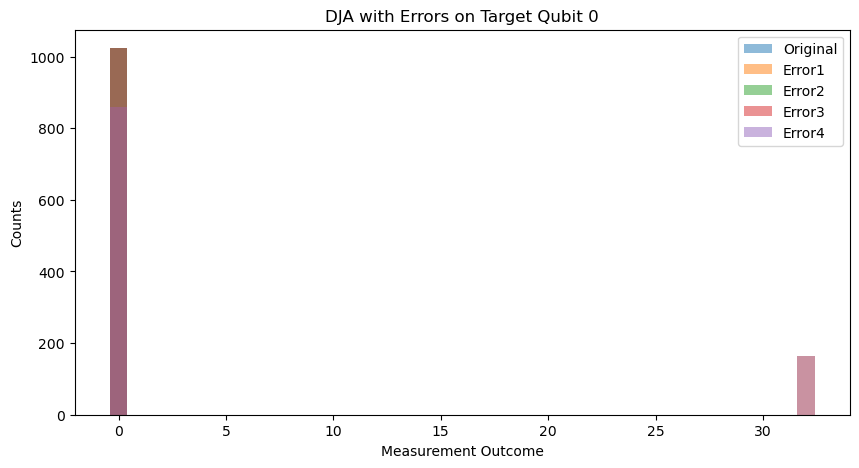

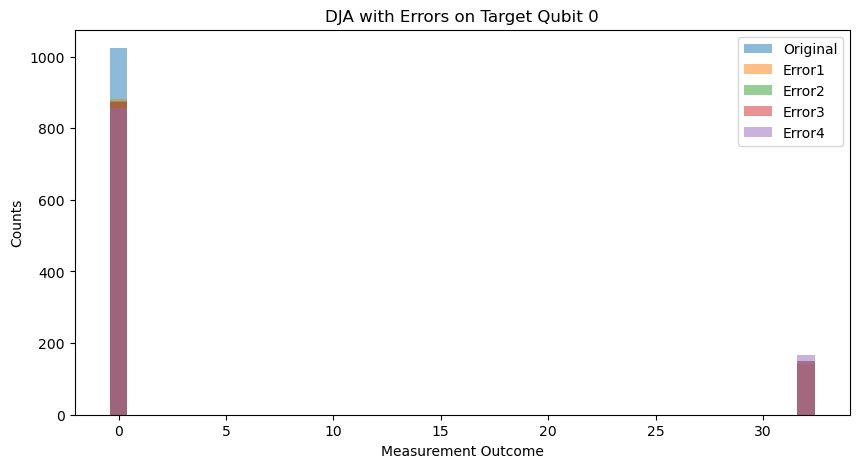

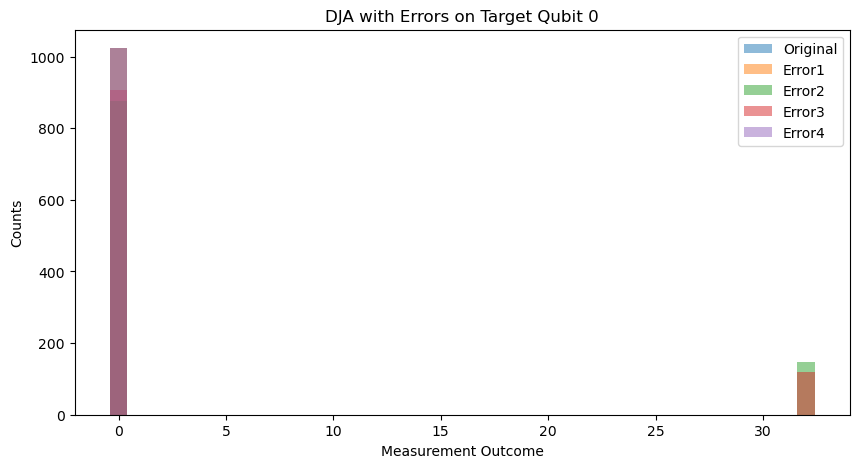

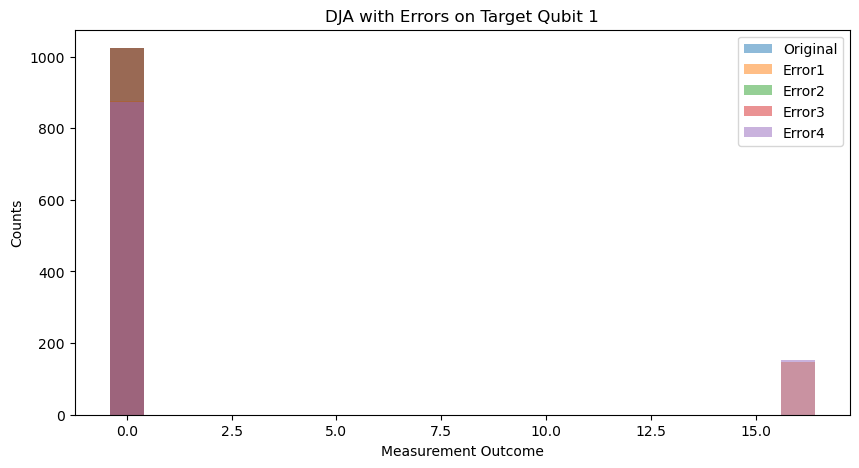

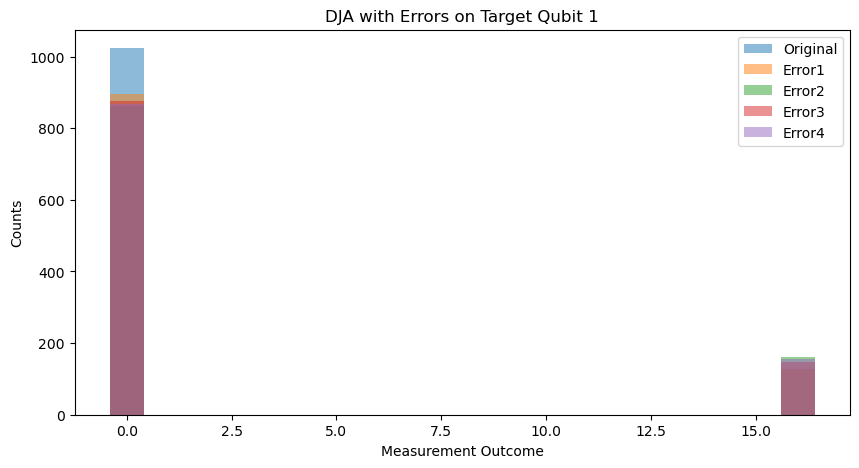

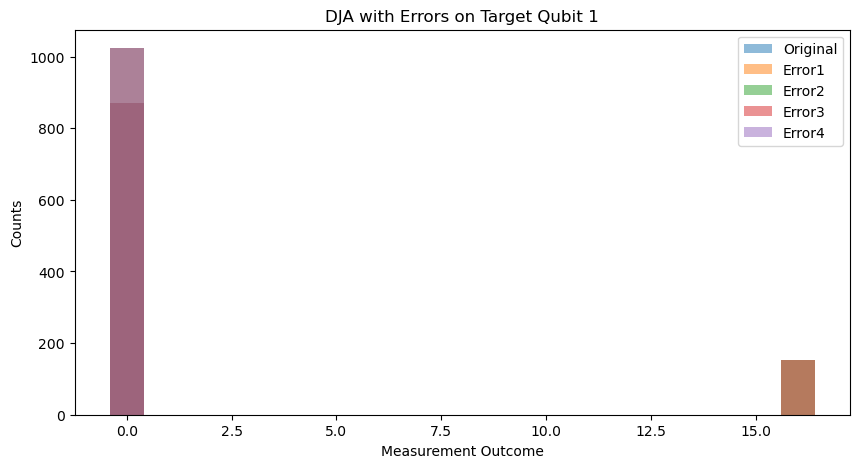

In [64]:
import matplotlib.pyplot as plt
def run_dja_with_errors(n, theta, target_qubit, axis, shots=1024):
    results = {}
    states = {
        "Original": deutsch_jozsa(n, f_constant_1),
        "Error1": deutsch_jozsa_error1(n, f_constant_1, theta, target_qubit, axis),
        "Error2": deutsch_jozsa_error2(n, f_constant_1, theta, target_qubit, axis),
        "Error3": deutsch_jozsa_error3(n, f_constant_1, theta, target_qubit, axis),
        "Error4": deutsch_jozsa_error4(n, f_constant_1, theta, target_qubit, axis)
    }
    
    for label, state in states.items():
        results[label] = sample_measurements_input(state, n, shots)
    return results

def plot_results(results, title):
    plt.figure(figsize=(10,5))
    for label, counts in results.items():
        states = list(counts.keys())
        freqs = list(counts.values())
        plt.bar(states, freqs, alpha=0.5, label=label)
    plt.xlabel("Measurement Outcome")
    plt.ylabel("Counts")
    plt.title(title)
    plt.legend()
    plt.show()
results = run_dja_with_errors(n=6, theta=np.pi/4, target_qubit=0, axis=(1,0,0))
plot_results(results, "DJA with Errors on Target Qubit 0")
results = run_dja_with_errors(n=6, theta=np.pi/4, target_qubit=0, axis=(0,1,0))
plot_results(results, "DJA with Errors on Target Qubit 0")
results = run_dja_with_errors(n=6, theta=np.pi/4, target_qubit=0, axis=(0,0,1))
plot_results(results, "DJA with Errors on Target Qubit 0")
results = run_dja_with_errors(n=6, theta=np.pi/4, target_qubit=1, axis=(1,0,0))
plot_results(results, "DJA with Errors on Target Qubit 1")
results = run_dja_with_errors(n=6, theta=np.pi/4, target_qubit=1, axis=(0,1,0))
plot_results(results, "DJA with Errors on Target Qubit 1")
results = run_dja_with_errors(n=6, theta=np.pi/4, target_qubit=1, axis=(0,0,1))
plot_results(results, "DJA with Errors on Target Qubit 1")


In [ ]:
import numpy as np

def deutsch_jozsa(n, f):
    """
    Deutsch–Jozsa Algorithm (DJA) to determine if a Boolean function f is constant or balanced.

    Parameters
    n : int
        Number of input qubits.
    f : callable
        Oracle function f(x) -> 0 or 1.

    Returns
        Final state vector after the algorithm.
    """
    total_qubits = n + 1
    state = initial_state(n)
    state = apply_hadamards(state, total_qubits)
    U = oracle_function(f, n)
    state = U(state)
    H_first_n = U_N_qubits([H] * n + [I])
    state = H_first_n @ state

    return state


def deutsch_jozsa_with_error(n, f, theta, target_qubit, axis):
    """
    Deutsch–Jozsa algorithm with a single-qubit rotation error applied
    at a specified stage.

    Parameters
    n : int
        Number of input qubits.
    f : callable
        Oracle function f(x) -> 0 or 1.
    theta : float
        Rotation angle in radians.
    target_qubit : int
        Qubit to apply the rotation.
    axis : tuple
        Rotation axis vector (nx, ny, nz).

    Returns
        Final state vector after the algorithm with error.
    """
    total_qubits = n + 1
    state = initial_state(n)
    R = rotation_gate(theta, axis)
    
    if error_stage == 1:
        state = U_one_gate(R, target_qubit, total_qubits) @ state
        
    state = apply_hadamards(state, total_qubits)
    
    if error_stage == 2:
        state = U_one_gate(R, target_qubit, total_qubits) @ state

    U = oracle_function(f, n)
    state = U(state)

    if error_stage == 3:
        state = U_one_gate(R, target_qubit, total_qubits) @ state

    H_first_n = U_N_qubits([H] * n + [I])
    state = H_first_n @ state

    if error_stage == 4:
        state = U_one_gate(R, target_qubit, total_qubits) @ state

    return state